# US Gas Prices (2024 – Present)

## Retail Gasoline Prices: Actual Prices & Year-over-Year Change

### Description

This notebook provides a technical visualization of U.S. retail gasoline price trends. It utilizes data from the Federal Reserve Economic Data (FRED) to compare:

- **Regular Grade:** Conventional Formulation (US Average)
- **Regular Grade:** All Formulations (US Average)
- **Unleaded Regular:** U.S. City Average
- **All Formulations:** U.S. City Average

The analysis tracks both actual weekly prices and year-over-year percentage changes to highlight gasoline price dynamics across formulation types and geographic aggregations.

---

## Objectives

- Analyze retail gasoline price trends from 2024 to present day
- Compare conventional vs. all-formulation pricing behaviors
- Identify periods of price acceleration and deceleration
- Provide a time-logged macroeconomic and energy market analysis

---

## Data Source

- Federal Reserve Economic Data (FRED)
  - `GASREGCOVW`: Regular Grade Conventional Gas Price, US Average (Weekly)
  - `GASREGW`: Regular Grade Gas Price, All Formulations, US Average (Weekly)
  - `APU000074714`: Average Price, Unleaded Regular, U.S. City Average
  - `APU00007471A`: Average Price, Gasoline, All Formulations, U.S. City Average

## Pre-Processing

### Install System Dependencies

In [1]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

### Import Python Libraries

In [2]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Define Global Functions 


In [3]:
def add_event_lines(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=10,
                     fontweight='bold')
            
def add_event_lines_small(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=5,
                     fontweight='bold')

### Standard Unit Initial Timeframe

In [4]:
start = datetime(2023, 4, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(weeks=52)

## US Gasoline Trends (April 2024 -Present)
### Key Events
- 2024 Presidential Election
- 2025 Inaugurattion of Donald J. Trump
- US Global Tariff Poliy enters effect
- 2025 Government Shutdown
- Iran War

In [5]:
gas_series = {
    'Regular, Conventional': {'id': 'GASREGCOVW', 'color': '#040404'},
    'Regular, All Formulations': {'id': 'GASREGW',    'color': '#e22222'},
    'Unleaded Regular, City Avg': {'id': 'APU000074714', 'color': '#05c10e'},
    'All Formulations, City Avg': {'id': 'APU00007471A', 'color': '#2e0cc3'}
}

events = [
    ('2024-11-04', '2024 Presidential Election'),
    ('2025-01-20', 'Donald Trump Enters Second Presidential Term'),
    ('2025-04-15', 'Trump Imposes Global Foreign Trade Policy'),
    ('2025-10-01', 'Congressional ACH Appropriation Shutdown'),
    ('2026-02-28', 'IRGC Closes Strait of Hormuz'),
]

raw_data = {}
transformed_data = {}


/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_81425/2199550037.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_wow = (df_raw.pct_change(periods=52) * 100)


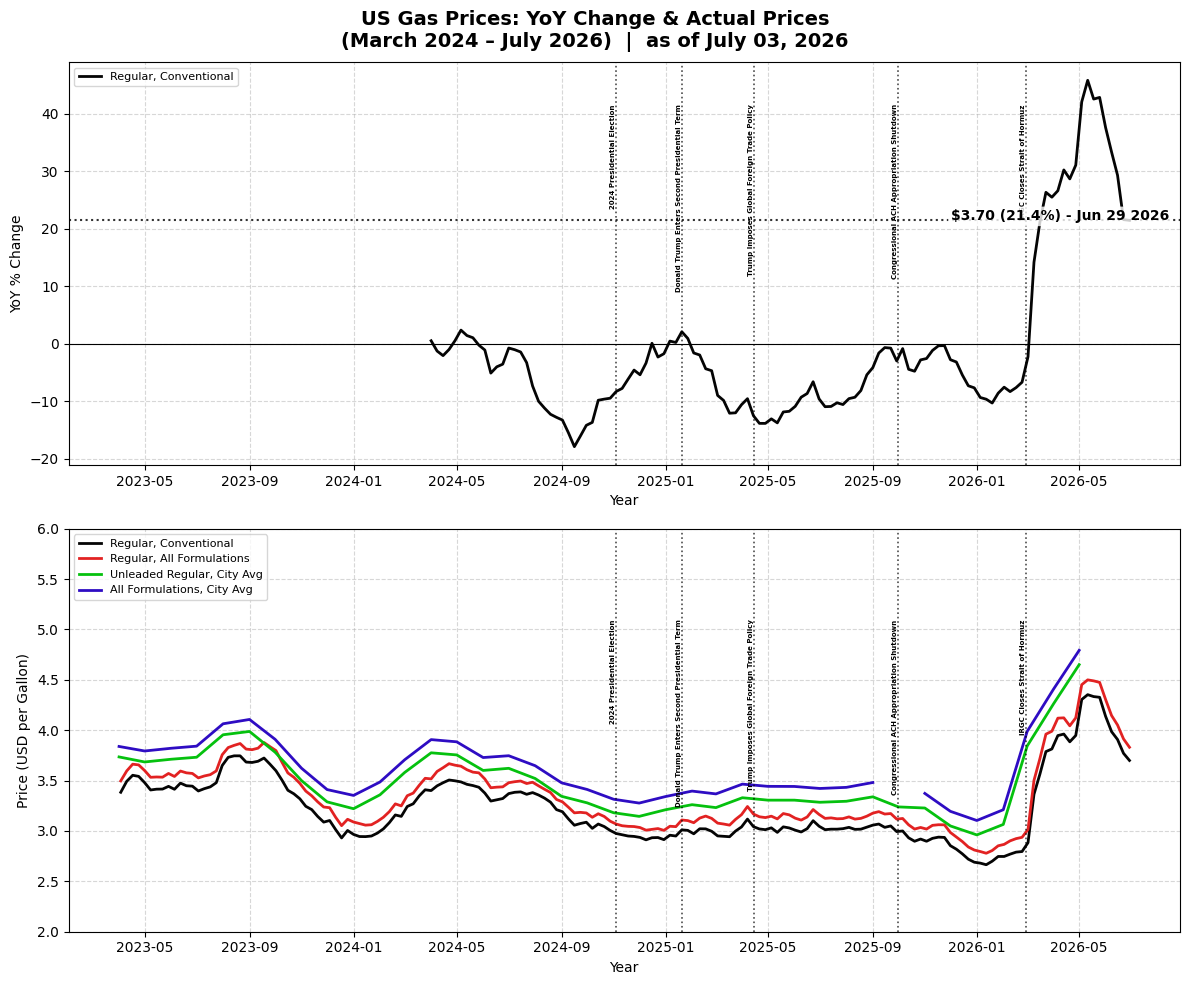

In [15]:


for label, meta in gas_series.items():
    df_raw = web.DataReader(meta['id'], 'fred', start, end)
    raw_data[label] = df_raw
    df_wow = (df_raw.pct_change(periods=52) * 100)
    transformed_data[label] = df_wow[df_wow.index >= plot_start]

r_date = transformed_data['Regular, Conventional'].index[-1]
r_val = transformed_data['Regular, Conventional'].iloc[-1, 0]
r_price = raw_data['Regular, Conventional'].iloc[-1, 0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Year-over-Year Percentage Change
# Note: Uncomment lines below to render all formulations on the YoY visualization
ax1.plot(transformed_data['Regular, Conventional'], label='Regular, Conventional', color=gas_series['Regular, Conventional']['color'], linewidth=2)
# ax1.plot(transformed_data['Regular, All Formulations'], label='Regular, All Formulations', color=gas_series['Regular, All Formulations']['color'], linewidth=2)
# ax1.plot(transformed_data['Unleaded Regular, City Avg'], label='Unleaded Regular, City Avg', color=gas_series['Unleaded Regular, City Avg']['color'], linewidth=2)
# ax1.plot(transformed_data['All Formulations, City Avg'], label='All Formulations, City Avg', color=gas_series['All Formulations, City Avg']['color'], linewidth=2)

ax1.set_ylabel('YoY % Change')
ax1.axhline(0, color='black', linewidth=0.8)

ax2.set_ylim(2, 6)
for label, df_raw in raw_data.items():
    ax2.plot(df_raw, label=label, color=gas_series[label]['color'], linewidth=2)
ax2.set_ylabel('Price (USD per Gallon)')

df_ref = list(raw_data.values())[0]

for ax in [ax1, ax2]:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8)
    
    y_pos = ax.get_ylim()[1] * 0.85
    for date_str, label in events:
        evt_date = pd.to_datetime(date_str)
        if df_ref.index.min() <= evt_date <= df_ref.index.max():
            ax.axvline(x=evt_date, 
                       color='black', 
                       linestyle=':', 
                       linewidth=1.2, 
                       alpha=0.7)
            ax.text(evt_date, 
                    y_pos, 
                    label, 
                    rotation=90, 
                    verticalalignment='top', 
                    horizontalalignment='right', 
                    fontsize=5, 
                    fontweight='bold')

ax1.tick_params(axis='x', labelbottom=True)
ax1.set_xlabel('Year')
ax2.set_xlabel('Year')

ax1.annotate(f"${r_price:.2f} ({r_val:.1f}%) - {r_date.strftime('%b %d %Y')}", 
             xy=(r_date, r_val), 
             textcoords="offset points", 
             xytext=(-50, 0), 
             ha='center', 
             weight='bold', 
             color='black',
             bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8, ec='none'))

ax1.axhline(y=r_val, 
            color="#000000", 
            linestyle=':', 
            linewidth=1.5, 
            alpha=0.8)

fig.suptitle(f'US Gas Prices: YoY Change & Actual Prices\n({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})  |  as of {str_current_date}',
             fontsize=14, 
             fontweight='bold')
plt.tight_layout()
plt.show()

# Conclusions and Observations

### Fuel and Energy – 25 June 2026

#### Prices are higher than a Rastafarian monk in a giraffe suit.

Further observation and analysis to come over the next few weeks, but the proof is in the MOU signed by the United States and Iran over the last few days.

##### Conventional Gas Prices

Since March 2026, gas prices have increased as much as 50% in some places, directly affecting energy costs in the United States and worldwide.

As of Monday, June 23, 2026, FRED reports that regular grade conventional gas reaced **$3.771/gallon**, down from relative highs of **$4.353/gallon**.

Nationalwide, regular grade fuel across all formulation reaced **$3.914/gallon**, down from highs of **$4.500/gallon**. 

Peak prices for conventional oil was recorded on May 11, 2026, and peak prices for all formulations of gasoline was recorded on May 18, 2026.

##### Prices in Urban Areas

Roughly 86% of the U.S. population resides in a metropolitan statistical area (MSA). Consider the fact that 98% of automobiles in daily commutes are gas-powered or hybrid.

Just about everyone you know is adjusting to rising costs of fuel and energy. In U.S. cities fuel prices peaked in May 2026.

In U.S. cities, regular unleaded averaged  **$4.611/gallon** and all formulas averaged **$4.793/gallon**.

These prices reflect a ***57.07%*** and ***54.41% increase*** since <u>January 2026</u>.

At that ttime, prices were **$3.104/gallon** and **2.961/gallon**, repectively.

##### The Good News

Prices are begninning to fall into a normalized range given the circumstances. 

##### The Bad News

Given the War in Iran is still a major player in the global economic landscape, it would not appear we are in the clear.

##### Closing

The EPA has rolled back regulattion on greenhouse emissions from U.S. vehicles. 

Removing the scientific justification for regulating climate pollution from cars and trucks, effectively repealed all subsequent GHG emission standards for light, medium, and heavy-duty vehicles.

Throw in the present administration's rollback of incentives for electric vehicles (EVs) and repeal of fuel economy standards, we may find ourselves forced to endure environmental concerns a bit longer.

My suggestion would be to plan your routes, turn the car off while idle, use fans, buy electric, and sit tight.

___

**Thank you for reading. It's been a while since I made a decent road trip, that was from Miami to Orlando last summer.**

**Now, I usually release these on Friday's but I have bigger fish to fry. <u>U.S. Real GPD and Wage Growth</u> and <u>U.S. Housing Market Indicies</u> were updated earlier today. Save yourself the trip.**
___



#### Update Schedule

- ***U.S. Regular - Jul 7, 2026***

    1. `GASREGCOVW`: **Conventional (Weekly)**
    2. `GASREGW`: **All Formulations (Weekly)**
    
- ***U.S. City Average - Jul 10, 2026***

    3. `APU000074714`: **Unleaded Regular**
    4. `APU00007471A`: **All Formulations**

#### Data Changelog / Notes

#### ***Review and analysis publishing on Friday, July 10, 2026, at 1:30 P.M. Pacific Time.***